In [ ]:
# prep the data

In [2]:
#!/usr/bin/env python3
"""
Build UAI cache files for July and August from the paired pooled CSVs:
  NDVI_wetlands/upland_rasteronly_<crop>_<year>_<month>_pooled.csv

Uses columns (from your header list):
  year, month, crop, label, wet_mean, upl_mean, wet_np, upl_np,
  wet_evi2_mean, upl_evi2_mean, wet_e2_np, upl_e2_np, ...

Computes:
  UAI_EVI2 = upl_evi2_mean - wet_evi2_mean
  UAI_NDVI = upl_mean      - wet_mean

Writes to Conowingo:
  $DML_NDVI_DATA_ROOT/analysis/uai_cache/
"""

from pathlib import Path
import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
IN_DIR = BASE / "NDVI_wetlands"

OUT_DIR = BASE / "analysis" / "uai_cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MONTHS_KEEP = {7, 8}

OUT_EVI2_07 = OUT_DIR / "UAI_EVI2_07_prepped.csv"
OUT_EVI2_08 = OUT_DIR / "UAI_EVI2_08_prepped.csv"
OUT_NDVI_07 = OUT_DIR / "UAI_NDVI_07_prepped.csv"
OUT_NDVI_08 = OUT_DIR / "UAI_NDVI_08_prepped.csv"

# Optional: minimum pixel counts to keep a pair-month
MIN_PIX_EVI2 = 1
MIN_PIX_NDVI = 1

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def normalize_crop(x: str) -> str:
    x = str(x).strip().lower()
    if x in {"corn", "maize"}:
        return "corn"
    if x in {"soy", "soybean", "soybeans"}:
        return "soy"
    return x

def safe_num(s):
    return pd.to_numeric(s, errors="coerce")

# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
def main():
    if not IN_DIR.exists():
        raise FileNotFoundError(f"Input folder not found: {IN_DIR}")

    files = sorted(IN_DIR.glob("upland_rasteronly_*_pooled.csv"))
    if not files:
        raise FileNotFoundError(f"No pooled pair CSVs found in {IN_DIR}")

    dfs = []
    for p in files:
        df = pd.read_csv(p)
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    # --- basic normalization ---
    df["year"]  = safe_num(df["year"]).astype("Int64")
    df["month"] = safe_num(df["month"]).astype("Int64")
    df["crop"]  = df["crop"].map(normalize_crop)

    # use 'label' as pair_id
    if "label" not in df.columns:
        raise ValueError("Expected a 'label' column to identify wetland/upland pairs.")
    df["pair_id"] = df["label"].astype(str)

    # keep July + August only
    df = df[df["month"].isin(MONTHS_KEEP)].copy()

    # --- compute UAI for EVI2 and NDVI ---
    # EVI2 means
    if not {"upl_evi2_mean", "wet_evi2_mean"}.issubset(df.columns):
        raise ValueError("Missing EVI2 mean columns. Need upl_evi2_mean and wet_evi2_mean.")
    df["upl_evi2_mean"] = safe_num(df["upl_evi2_mean"])
    df["wet_evi2_mean"] = safe_num(df["wet_evi2_mean"])
    df["UAI_EVI2"] = df["upl_evi2_mean"] - df["wet_evi2_mean"]

    # NDVI means (assumed)
    if not {"upl_mean", "wet_mean"}.issubset(df.columns):
        raise ValueError("Missing NDVI mean columns. Need upl_mean and wet_mean.")
    df["upl_mean"] = safe_num(df["upl_mean"])
    df["wet_mean"] = safe_num(df["wet_mean"])
    df["UAI_NDVI"] = df["upl_mean"] - df["wet_mean"]

    # Pixel counts (optional but useful)
    # EVI2 counts appear as wet_e2_np / upl_e2_np in your header list
    if "wet_e2_np" in df.columns and "upl_e2_np" in df.columns:
        df["wet_evi2_np"] = safe_num(df["wet_e2_np"])
        df["upl_evi2_np"] = safe_num(df["upl_e2_np"])
    elif "wet_evi2_np" in df.columns and "upl_evi2_np" in df.columns:
        df["wet_evi2_np"] = safe_num(df["wet_evi2_np"])
        df["upl_evi2_np"] = safe_num(df["upl_evi2_np"])
    else:
        # fallback: no counts
        df["wet_evi2_np"] = np.nan
        df["upl_evi2_np"] = np.nan

    if "wet_np" in df.columns and "upl_np" in df.columns:
        df["wet_ndvi_np"] = safe_num(df["wet_np"])
        df["upl_ndvi_np"] = safe_num(df["upl_np"])
    else:
        df["wet_ndvi_np"] = np.nan
        df["upl_ndvi_np"] = np.nan

    # --- split + write caches ---
    def write_cache(metric: str, month: int, outpath: Path):
        if metric == "EVI2":
            cols = ["year", "month", "crop", "pair_id", "UAI_EVI2",
                    "wet_evi2_mean", "upl_evi2_mean", "wet_evi2_np", "upl_evi2_np"]
            d = df[df["month"] == month].copy()
            # basic pixel-count screen if available
            if d["wet_evi2_np"].notna().any() and d["upl_evi2_np"].notna().any():
                d = d[(d["wet_evi2_np"] >= MIN_PIX_EVI2) & (d["upl_evi2_np"] >= MIN_PIX_EVI2)]
            d = d[cols].rename(columns={"UAI_EVI2": "UAI"})
        else:
            cols = ["year", "month", "crop", "pair_id", "UAI_NDVI",
                    "wet_mean", "upl_mean", "wet_ndvi_np", "upl_ndvi_np"]
            d = df[df["month"] == month].copy()
            if d["wet_ndvi_np"].notna().any() and d["upl_ndvi_np"].notna().any():
                d = d[(d["wet_ndvi_np"] >= MIN_PIX_NDVI) & (d["upl_ndvi_np"] >= MIN_PIX_NDVI)]
            d = d[cols].rename(columns={"UAI_NDVI": "UAI"})

        d = d.dropna(subset=["year", "month", "crop", "pair_id", "UAI"]).copy()
        d = d.sort_values(["crop", "year", "pair_id"]).reset_index(drop=True)
        d.to_csv(outpath, index=False)

        yrs = sorted(d["year"].dropna().astype(int).unique().tolist())
        print(f"[OK] Wrote {outpath}")
        print(f"     metric={metric} month={month:02d} rows={len(d):,} years={yrs[0]}–{yrs[-1]}")

    write_cache("EVI2", 7, OUT_EVI2_07)
    write_cache("EVI2", 8, OUT_EVI2_08)
    write_cache("NDVI", 7, OUT_NDVI_07)
    write_cache("NDVI", 8, OUT_NDVI_08)

    print(f"[DONE] UAI caches saved in: {OUT_DIR}")

if __name__ == "__main__":
    main()


[OK] Wrote /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/uai_cache/UAI_EVI2_07_prepped.csv
     metric=EVI2 month=07 rows=2,577,276 years=2003–2024
[OK] Wrote /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/uai_cache/UAI_EVI2_08_prepped.csv
     metric=EVI2 month=08 rows=2,456,259 years=2003–2024
[OK] Wrote /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/uai_cache/UAI_NDVI_07_prepped.csv
     metric=NDVI month=07 rows=2,574,849 years=2003–2024
[OK] Wrote /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/uai_cache/UAI_NDVI_08_prepped.csv
     metric=NDVI month=08 rows=2,575,012 years=2003–2024
[DONE] UAI caches saved in: /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/uai_cache


In [ ]:
# new hybrid figure

[SAVED] /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure 5 UAI/Figure_5_UAI_HYBRID_4panel_cornJULY_soyAUG.png
[SAVED] /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure 5 UAI/Figure_5_UAI_HYBRID_4panel_cornJULY_soyAUG.jpg


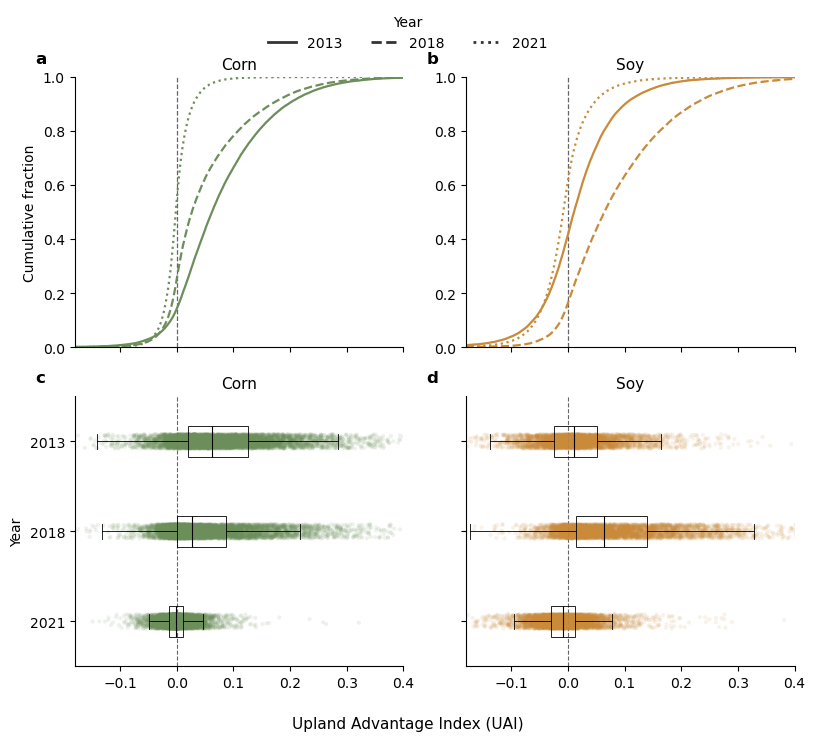

In [24]:
#!/usr/bin/env python3
"""
HYBRID UAI figure set:
  - Main Figure 5: 6-panel ECDFs (Option 1)
  - Supplement: 6-panel paired dot + box overlay (Option 2)

Mixed months (explicit):
  - Corn uses JULY (07) UAI (EVI2-based)
  - Soy uses AUGUST (08) UAI (EVI2-based)

Inputs:
  UAI_EVI2_07_prepped.csv
  UAI_EVI2_08_prepped.csv
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
YEARS = [2013, 2018, 2021]
CROPS = ["corn", "soy"]

# Explicit mixed-month rule (edit here if needed)
CROP_TO_MONTH = {"corn": 7, "soy": 8}

# Colors (match your scheme)
CORN_COLOR = "#4C8A2F"
SOY_COLOR  = "#D9842B"
CORN_COLOR = "#6B8E5A"
SOY_COLOR  = "#C98A3A"
CROP_TO_COLOR = {"corn": CORN_COLOR, "soy": SOY_COLOR}

# Aesthetics
FIGSIZE = (8.0, 8.0)
MIN_N_PER_PANEL = 20

# Dot plot settings (supp figure)
DOT_ALPHA = 0.11
DOT_SIZE = 9
JITTER = 0.08  # vertical jitter for dots

# ECDF settings
ECDF_LINEWIDTH = 1.6

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
CACHE_DIR = BASE / "analysis" / "uai_cache"
UAI_JULY_CSV   = CACHE_DIR / "UAI_EVI2_07_prepped.csv"
UAI_AUGUST_CSV = CACHE_DIR / "UAI_EVI2_08_prepped.csv"

OUT_ROOT = BASE / "Figures" / "Figure 5 UAI"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

OUT_ECDF_PNG = OUT_ROOT / "Figure_5_UAI_6panel_ECDF_cornJULY_soyAUG.png"
OUT_ECDF_JPG = OUT_ROOT / "Figure_5_UAI_6panel_ECDF_cornJULY_soyAUG.jpg"

OUT_DOTBOX_PNG = OUT_ROOT / "Figure_S_UAI_6panel_DotBox_cornJULY_soyAUG.png"
OUT_DOTBOX_JPG = OUT_ROOT / "Figure_S_UAI_6panel_DotBox_cornJULY_soyAUG.jpg"

DOT_FRACTION = 0.10     # plot 12% of points
DOT_MAX = 10000         # hard cap per panel (safety)

OUT_HYBRID_PNG = OUT_ROOT / "Figure_5_UAI_HYBRID_4panel_cornJULY_soyAUG.png"
OUT_HYBRID_JPG = OUT_ROOT / "Figure_5_UAI_HYBRID_4panel_cornJULY_soyAUG.jpg"


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def normalize_crop(series: pd.Series) -> pd.Series:
    m = {
        "corn": "corn", "maize": "corn",
        "soy": "soy", "soybean": "soy", "soybeans": "soy",
    }
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(lambda x: m.get(x, x))
    )

def ecdf(vals: np.ndarray):
    """Return x,y for ECDF step plot."""
    x = np.sort(vals)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

# --- add near helpers ---
def hex_to_rgb01(hex_color: str):
    hex_color = hex_color.strip().lstrip("#")
    return tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))

def rgb01_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(
        int(round(rgb[0]*255)), int(round(rgb[1]*255)), int(round(rgb[2]*255))
    )

def lighten_hex(hex_color: str, amount: float):
    """
    amount in [0,1]; 0 = original, 1 = white
    """
    r, g, b = hex_to_rgb01(hex_color)
    r = r + (1 - r) * amount
    g = g + (1 - g) * amount
    b = b + (1 - b) * amount
    return rgb01_to_hex((r, g, b))

# Year styling (edit as desired)
YEAR_STYLE = {
    2013: dict(ls="-",  lw=1.8, lighten=0.00),
    2018: dict(ls="--", lw=1.8, lighten=0.25),
    2021: dict(ls=":",  lw=2.0, lighten=0.45),
}

from matplotlib.lines import Line2D

def plot_ecdf_overlay_2panel(df: pd.DataFrame):
    xmin, xmax = common_xlim(df)

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6), sharex=True, sharey=True)

    # year style: ONLY linestyle (neutral legend)
    YEAR_LS = {2013: "-", 2018: "--", 2021: ":"}

    for j, crop in enumerate(CROPS):
        ax = axes[j]
        color = CROP_TO_COLOR.get(crop, "0.3")

        for year in YEARS:
            subset = df[(df["year"] == year) & (df["crop"] == crop)]
            vals = subset["UAI"].dropna().to_numpy(dtype=float)
            if vals.size < MIN_N_PER_PANEL:
                continue

            x, y = ecdf(vals)
            ax.step(
                x, y, where="post",
                color=color,
                linestyle=YEAR_LS[year],
                linewidth=ECDF_LINEWIDTH,
            )

        ax.axvline(0.0, color="0.4", linestyle="--", linewidth=0.9)
        ax.set_title(crop.capitalize(), fontsize=11)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0, 1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Cumulative fraction", fontsize=10)
    fig.text(0.5, 0.02, "Upland Advantage Index (UAI)", ha="center", fontsize=11)

    # Neutral legend (black/gray) showing ONLY year linestyles
    handles = [
        Line2D([0], [0], color="0.2", lw=2.0, linestyle=YEAR_LS[y], label=str(y))
        for y in YEARS
    ]
    fig.legend(handles=handles, title="Year", loc="upper center",
               ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.05))

    # Panel labels a, b
    axes[0].text(-0.12, 1.04, "a", transform=axes[0].transAxes,
                 fontsize=12, fontweight="bold", va="bottom", ha="left")
    axes[1].text(-0.12, 1.04, "b", transform=axes[1].transAxes,
                 fontsize=12, fontweight="bold", va="bottom", ha="left")

    plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.92])

    fig.savefig(OUT_ECDF_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(OUT_ECDF_JPG, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {OUT_ECDF_PNG}")
    print(f"[SAVED] {OUT_ECDF_JPG}")


def panel_label_stats(vals: np.ndarray):
    med = float(np.median(vals))
    q1, q3 = [float(x) for x in np.percentile(vals, [25, 75])]
    frac_pos = float((vals > 0).mean())
    return med, q1, q3, frac_pos

def common_xlim(df, force_xmin=-0.18, force_xmax=0.40):
    u = df["UAI"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if u.size == 0:
        raise ValueError("No finite UAI values available for xlim.")
    lo, hi = np.percentile(u, [1, 99])
    pad = 0.01
    xmin = float(lo - pad)
    xmax = float(hi + pad)
    # force wider range to avoid clipping tails + keep comparability
    xmin = min(xmin, force_xmin)
    xmax = max(xmax, force_xmax)
    return xmin, xmax

def load_mixed_month_df():
    if not UAI_JULY_CSV.exists():
        raise FileNotFoundError(f"Missing July cache: {UAI_JULY_CSV}")
    if not UAI_AUGUST_CSV.exists():
        raise FileNotFoundError(f"Missing August cache: {UAI_AUGUST_CSV}")

    df_jul = pd.read_csv(UAI_JULY_CSV)
    df_aug = pd.read_csv(UAI_AUGUST_CSV)

    # normalize
    for d in (df_jul, df_aug):
        d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")
        d["month"] = pd.to_numeric(d.get("month", np.nan), errors="coerce").astype("Int64")
        d["crop"] = normalize_crop(d["crop"])
        d["UAI"] = pd.to_numeric(d["UAI"], errors="coerce")
        d.replace([np.inf, -np.inf], np.nan, inplace=True)

    # apply explicit mixed-month rule:
    parts = []
    # corn from July file, soy from August file (matches your current intent)
    parts.append(df_jul[df_jul["crop"].eq("corn")].copy())
    parts.append(df_aug[df_aug["crop"].eq("soy")].copy())

    df = pd.concat(parts, ignore_index=True)

    # keep only requested years/crops
    df = df[df["year"].isin(YEARS) & df["crop"].isin(CROPS)].copy()

    # add "plot_month" derived from rule (for provenance / captions if needed)
    df["plot_month"] = df["crop"].map(CROP_TO_MONTH).astype("Int64")

    # drop missing essentials
    df = df.dropna(subset=["year", "crop", "UAI"]).copy()

    return df

from matplotlib.lines import Line2D
import os

def draw_ecdf_overlay(ax, df: pd.DataFrame, crop: str, xmin: float, xmax: float):
    YEAR_LS = {2013: "-", 2018: "--", 2021: ":"}
    color = CROP_TO_COLOR.get(crop, "0.3")

    for year in YEARS:
        subset = df[(df["year"] == year) & (df["crop"] == crop)]
        vals = subset["UAI"].dropna().to_numpy(dtype=float)
        if vals.size < MIN_N_PER_PANEL:
            continue
        x, y = ecdf(vals)
        ax.step(x, y, where="post", color=color, linestyle=YEAR_LS[year], linewidth=ECDF_LINEWIDTH)

    # zero line (behind)
    ax.axvline(0.0, color="0.4", linestyle="--", linewidth=0.9, zorder=1)

    ax.set_title(crop.capitalize(), fontsize=11)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def draw_dotbox_stacked(ax, df: pd.DataFrame, crop: str, xmin: float, xmax: float, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    color = CROP_TO_COLOR.get(crop, "0.3")
    year_to_y = {y: (len(YEARS) - 1 - i) for i, y in enumerate(YEARS)}  # 2013 top

    for year in YEARS:
        subset = df[(df["year"] == year) & (df["crop"] == crop)]
        vals = subset["UAI"].dropna().to_numpy(dtype=float)
        if vals.size < MIN_N_PER_PANEL:
            continue

        y0 = year_to_y[year]

        # subsample dots
        n = vals.size
        k = int(min(DOT_MAX, max(1, round(DOT_FRACTION * n))))
        idx = rng.choice(n, size=k, replace=False)
        vals_plot = vals[idx]
        yjit = rng.uniform(-JITTER, JITTER, size=k) + y0

        # dots
        ax.scatter(
            vals_plot, yjit,
            s=DOT_SIZE,
            alpha=DOT_ALPHA,
            color=color,
            edgecolors="none",
            rasterized=True,
            zorder=2,
        )

        # boxplot (outline)
        ax.boxplot(
            vals,
            vert=False,
            positions=[y0],
            widths=0.34,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor="none", edgecolor="black", linewidth=0.6),
            medianprops=dict(color="black", linewidth=0.8),
            whiskerprops=dict(color="black", linewidth=0.6),
            capprops=dict(color="black", linewidth=0.6),
            zorder=4,
        )

    # zero line (behind)
    ax.axvline(0.0, color="0.4", linestyle="--", linewidth=0.8, zorder=1)

    ax.set_title(crop.capitalize(), fontsize=11)
    ax.set_xlim(xmin, xmax)

    ax.set_yticks([year_to_y[y] for y in YEARS])
    ax.set_yticklabels([str(y) for y in YEARS], fontsize=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# PLOTTERS
# ------------------------------------------------------------

def plot_dotbox_stacked_2panel(df: pd.DataFrame):
    xmin, xmax = common_xlim(df)

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 4.8), sharex=True, sharey=True)
    rng = np.random.default_rng(42)

    year_to_y = {y: (len(YEARS) - 1 - i) for i, y in enumerate(YEARS)}  # 2013 top

    for j, crop in enumerate(CROPS):
        ax = axes[j]
        color = CROP_TO_COLOR.get(crop, "0.3")

        for year in YEARS:
            subset = df[(df["year"] == year) & (df["crop"] == crop)]
            vals = subset["UAI"].dropna().to_numpy(dtype=float)
            if vals.size < MIN_N_PER_PANEL:
                continue

            y0 = year_to_y[year]

            # subsample dots
            n = vals.size
            k = int(min(DOT_MAX, max(1, round(DOT_FRACTION * n))))
            idx = rng.choice(n, size=k, replace=False)
            vals_plot = vals[idx]
            yjit = rng.uniform(-JITTER, JITTER, size=k) + y0

            # --- dots (subsampled) ---
            ax.scatter(
                vals_plot, yjit,
                s=DOT_SIZE,
                alpha=DOT_ALPHA,                 # <- lower alpha so boxes show
                color=color,
                edgecolors="none",
                rasterized=True,
                zorder=2,
            )


            # --- boxplot (all vals), outlined and on top ---
            ax.boxplot(
                vals,
                vert=False,
                positions=[y0],
                widths=0.34,
                showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor="none", edgecolor="black", linewidth=0.5),  # <- no fill + bold outline
                medianprops=dict(color="black", linewidth=0.5),                     # <- emphasize median
                whiskerprops=dict(color="black", linewidth=0.5),
                capprops=dict(color="black", linewidth=0.5),
                zorder=4,
            )

        ax.axvline(0.0, color="0.4", linestyle="--", linewidth=0.8, zorder=1)

        ax.set_title(crop.capitalize(), fontsize=11)
        ax.set_xlim(xmin, xmax)

        ax.set_yticks([year_to_y[y] for y in YEARS])
        ax.set_yticklabels([str(y) for y in YEARS], fontsize=10)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if j == 1:
            ax.set_ylabel("")
        else:
            ax.set_ylabel("Year", fontsize=10)

    fig.text(0.5, 0.02, "Upland Advantage Index (UAI)", ha="center", fontsize=11)

    # Panel labels c, d
    axes[0].text(-0.12, 1.04, "c", transform=axes[0].transAxes,
                 fontsize=12, fontweight="bold", va="bottom", ha="left")
    axes[1].text(-0.12, 1.04, "d", transform=axes[1].transAxes,
                 fontsize=12, fontweight="bold", va="bottom", ha="left")

    plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.98])




    fig.savefig(OUT_DOTBOX_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DOTBOX_JPG, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {OUT_DOTBOX_PNG}")
    print(f"[SAVED] {OUT_DOTBOX_JPG}")

def plot_hybrid_4panel(df: pd.DataFrame):
    xmin, xmax = common_xlim(df)
    rng = np.random.default_rng(42)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(8.6, 7.6),
        sharex="col",
        sharey=False
    )

    # --- top row: ECDF overlays ---
    draw_ecdf_overlay(axes[0, 0], df, "corn", xmin, xmax)
    draw_ecdf_overlay(axes[0, 1], df, "soy",  xmin, xmax)

    axes[0, 0].set_ylabel("Cumulative fraction", fontsize=10)
    axes[0, 1].set_ylabel("")

    # --- bottom row: dot+box stacked ---
    draw_dotbox_stacked(axes[1, 0], df, "corn", xmin, xmax, rng=rng)
    draw_dotbox_stacked(axes[1, 1], df, "soy",  xmin, xmax, rng=rng)

    axes[1, 0].set_ylabel("Year", fontsize=10)
    axes[1, 1].set_ylabel("")
    axes[1, 1].set_yticklabels([])  # keep only left y labels (optional)

    # Panel labels
    axes[0, 0].text(-0.12, 1.04, "a", transform=axes[0, 0].transAxes,
                    fontsize=12, fontweight="bold", va="bottom", ha="left")
    axes[0, 1].text(-0.12, 1.04, "b", transform=axes[0, 1].transAxes,
                    fontsize=12, fontweight="bold", va="bottom", ha="left")
    axes[1, 0].text(-0.12, 1.04, "c", transform=axes[1, 0].transAxes,
                    fontsize=12, fontweight="bold", va="bottom", ha="left")
    axes[1, 1].text(-0.12, 1.04, "d", transform=axes[1, 1].transAxes,
                    fontsize=12, fontweight="bold", va="bottom", ha="left")

    # Neutral year legend (linestyle only) for top row
    YEAR_LS = {2013: "-", 2018: "--", 2021: ":"}
    handles = [Line2D([0], [0], color="0.2", lw=2.0, linestyle=YEAR_LS[y], label=str(y)) for y in YEARS]
    fig.legend(handles=handles, title="Year", loc="upper center",
               ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.985))

    # One shared x label
    fig.text(0.5, 0.03, "Upland Advantage Index (UAI)", ha="center", fontsize=11)

    # layout
    plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.94])

    # save
    fig.savefig(OUT_HYBRID_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(OUT_HYBRID_JPG, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {OUT_HYBRID_PNG}")
    print(f"[SAVED] {OUT_HYBRID_JPG}")


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
if __name__ == "__main__":
    df_plot = load_mixed_month_df()
    plot_hybrid_4panel(df_plot)




In [ ]:
# figure

[SAVED] /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure 5 UAI/Figure_5_UAI_6panel_EVI2_cornJULY_soyAUG.png
[SAVED] /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure 5 UAI/Figure_5_UAI_6panel_EVI2_cornJULY_soyAUG.jpg


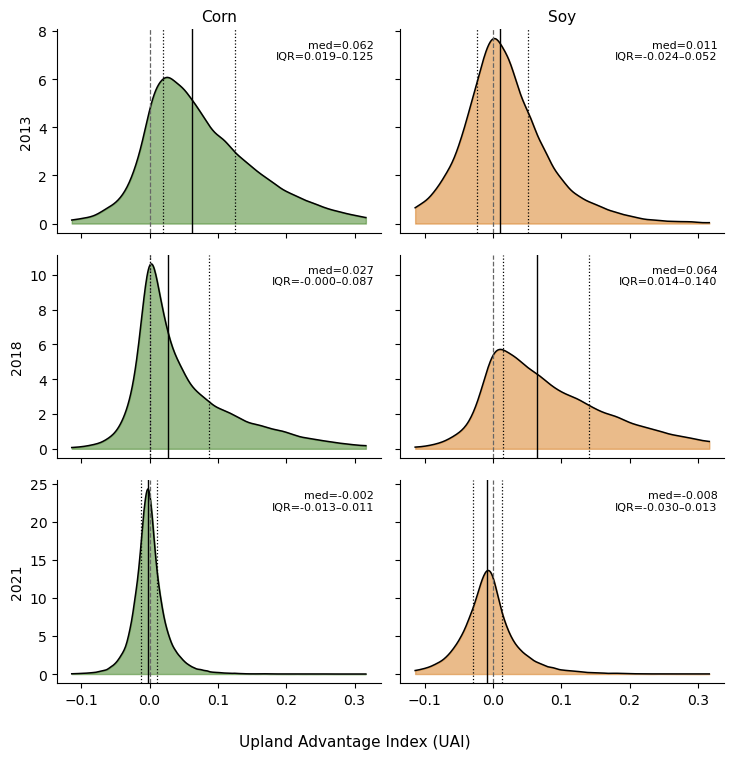

In [20]:
#!/usr/bin/env python3
"""
6-panel UAI KDE figure using mixed months:
  - Corn panels use JULY UAI (EVI2-based)
  - Soy panels use AUGUST UAI (EVI2-based)

Input prepped files (from the cache-builder script):
  $DML_NDVI_DATA_ROOT/analysis/uai_cache/UAI_EVI2_07_prepped.csv
  $DML_NDVI_DATA_ROOT/analysis/uai_cache/UAI_EVI2_08_prepped.csv

Output:
  Figure_UAI_6panel_EVI2_cornJULY_soyAUG.png/.jpg
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

# Years shown as rows
YEARS = [2013, 2018, 2021]   # tweak anytime

# Columns (left: corn, right: soy)
CROPS = ["corn", "soy"]

# Crop colors (consistent with your other figures)
CORN_COLOR = "#4C8A2F"
SOY_COLOR  = "#D9842B"

# KDE / panel aesthetics
FIGSIZE         = (8.0, 8.0)   # 3 rows x 2 cols
BANDWIDTH_ADJ   = 0.9
LINEWIDTH       = 1.1
ALPHA_FILL      = 0.55
MIN_N_PER_PANEL = 20

# Conowingo cache inputs
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
CACHE_DIR = BASE / "analysis" / "uai_cache"
UAI_JULY_CSV   = CACHE_DIR / "UAI_EVI2_07_prepped.csv"
UAI_AUGUST_CSV = CACHE_DIR / "UAI_EVI2_08_prepped.csv"

# ------------------------------------------------------------
# OUTPUT PATHS (Conowingo)
# ------------------------------------------------------------
OUT_ROOT = (
    Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
    / "Figures"
    / "Figure 5 UAI"
)
OUT_ROOT.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_ROOT / "Figure_5_UAI_6panel_EVI2_cornJULY_soyAUG.png"
OUT_JPG = OUT_ROOT / "Figure_5_UAI_6panel_EVI2_cornJULY_soyAUG.jpg"
OUT_JPG = OUT_ROOT / "Figure_5_UAI_6panel_EVI2_cornJULY_soyAUG.jpg"


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def normalize_crop(series: pd.Series) -> pd.Series:
    m = {
        "corn": "corn", "maize": "corn",
        "soy": "soy", "soybean": "soy", "soybeans": "soy",
    }
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(lambda x: m.get(x, x))
    )


# ------------------------------------------------------------
# PLOTTING FUNCTION
# ------------------------------------------------------------
def plot_six_panel_kde(df: pd.DataFrame):
    """
    Make a 3x2 panel figure of UAI distributions:

      Rows: YEARS (in order)
      Cols: CROPS (left: corn [JULY], right: soy [AUGUST])

    Each panel shows a KDE of UAI for (year, crop),
    with vertical lines for median and IQR, and a dashed
    reference line at UAI = 0.
    """
    df = df.copy()

    # Ensure correct types
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["crop"] = normalize_crop(df["crop"])
    df["UAI"]  = pd.to_numeric(df["UAI"], errors="coerce")

    # Filter to requested years and crops
    df = df[df["year"].isin(YEARS) & df["crop"].isin(CROPS)].copy()

    if df.empty:
        raise ValueError("No data left after filtering to requested YEARS and CROPS.")

    # Establish a common x-range across all selected panels
    uvals = df["UAI"].replace([np.inf, -np.inf], np.nan).dropna().values
    umin, umax = np.percentile(uvals, [1, 99])
    margin = 0.01
    xmin = float(umin - margin)
    xmax = float(umax + margin)
    x_grid = np.linspace(xmin, xmax, 400)

    # Set up figure
    n_rows = len(YEARS)
    n_cols = len(CROPS)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=FIGSIZE, sharex=True, sharey="row"
    )

    # Ensure axes is always 2D
    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    crop_to_color = {"corn": CORN_COLOR, "soy": SOY_COLOR}

    for i, year in enumerate(YEARS):
        for j, crop in enumerate(CROPS):
            ax = axes[i, j]
            subset = df[(df["year"] == year) & (df["crop"] == crop)]

            vals = subset["UAI"].dropna().values.astype(float)
            if vals.size < MIN_N_PER_PANEL:
                ax.text(
                    0.5, 0.5, "Insufficient data",
                    transform=ax.transAxes,
                    ha="center", va="center",
                    fontsize=8,
                )
                ax.set_axis_off()
                continue

            # Summary stats
            med = float(np.median(vals))
            q1, q3 = [float(x) for x in np.percentile(vals, [25, 75])]

            # KDE
            kde = gaussian_kde(vals)
            kde.set_bandwidth(kde.factor * BANDWIDTH_ADJ)
            density = kde(x_grid)

            color = crop_to_color.get(crop, "gray")

            # Filled density + outline
            ax.fill_between(x_grid, 0, density, color=color, alpha=ALPHA_FILL)
            ax.plot(x_grid, density, color="black", linewidth=LINEWIDTH)

            # Reference line at UAI = 0
            ax.axvline(0.0, color="0.4", linestyle="--", linewidth=0.9)

            # Median (solid) and IQR (dotted)
            ax.axvline(med, color="black", linestyle="-", linewidth=1.0)
            ax.axvline(q1,  color="black", linestyle=":", linewidth=0.9)
            ax.axvline(q3,  color="black", linestyle=":", linewidth=0.9)

            # Annotation
            ax.text(
                0.98, 0.95,
                f"med={med:.3f}\nIQR={q1:.3f}–{q3:.3f}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=8,
            )

            # Aesthetics
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Left column: year labels
            if j == 0:
                ax.set_ylabel(str(int(year)), fontsize=10)
            else:
                ax.set_ylabel("")

            # Column titles (top row only)
            if i == 0:
                ax.set_title(crop.capitalize(), fontsize=11)

    # Shared x-label (note mixed months!)
    fig.text(
        0.5, 0.04,
        "Upland Advantage Index (UAI)",
        ha="center",
        fontsize=11,
    )

    plt.tight_layout(rect=[0.05, 0.07, 0.98, 0.98])

    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


# ------------------------------------------------------------
# LOAD DATA + CALL FUNCTION
# ------------------------------------------------------------
if __name__ == "__main__":
    if not UAI_JULY_CSV.exists():
        raise FileNotFoundError(f"Missing July cache: {UAI_JULY_CSV}")
    if not UAI_AUGUST_CSV.exists():
        raise FileNotFoundError(f"Missing August cache: {UAI_AUGUST_CSV}")

    df_jul = pd.read_csv(UAI_JULY_CSV)
    df_aug = pd.read_csv(UAI_AUGUST_CSV)

    # Corn from July, soy from August
    df_plot = pd.concat(
        [
            df_jul[normalize_crop(df_jul["crop"]).eq("corn")].copy(),
            df_aug[normalize_crop(df_aug["crop"]).eq("soy")].copy(),
        ],
        ignore_index=True,
    )

    plot_six_panel_kde(df_plot)
